# Stage 3 — Mars interactive network exploration

_Pipeline stage 3 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## Mars valley networks — the target landscape, characterized

Unlike Earth, Mars networks are **already-mapped valley-network polylines** (391
networks), not DEM-derived. Their geometry reflects whatever fluvial signal survived
~3.5 Gyr of degradation. The Earth→Mars transfer is only valid if the Earth training
networks have **comparable drainage density**, so we characterize the Mars Dd
distribution, Strahler structure, and geography here — this is the target Stage 4
calibrates Earth against.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


In [2]:
from channel_heads.dd_calibration import mars_network_table, mars_network_strahler
gpkg = MARS_DIR / 'topology' / 'mars_vn_topology_model_ready.gpkg'
net = mars_network_table(gpkg if gpkg.exists() else None)
print(f'Mars networks: {len(net)}  (status ok: {int((net.status=="ok").sum())})')
net[['length_km','hull_area_km2','dd_hull_km_km2']].describe().round(2)

Mars networks: 391  (status ok: 391)


,length_km,hull_area_km2,dd_hull_km_km2
count,391.00,391.00,391.00
mean,171.14,1531.35,0.24
std,172.78,7008.23,0.12
min,28.44,50.40,0.02
25%,80.76,280.48,0.16
50%,122.41,567.49,0.22
75%,213.14,1239.09,0.30
max,2313.50,133510.85,0.73


### 1 · Drainage-density and size distributions

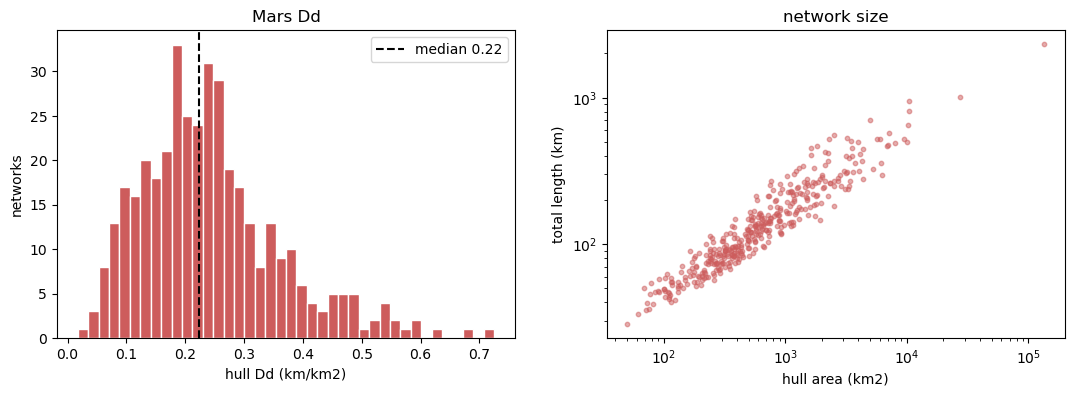

Mars median Dd = 0.224 km/km2 — the value the Earth regimes bracket.


In [3]:
ok = net[net.status == 'ok']
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
dd = ok.dd_hull_km_km2.dropna()
ax[0].hist(dd, bins=40, color='indianred', edgecolor='white')
ax[0].axvline(dd.median(), color='k', ls='--', label=f'median {dd.median():.2f}')
ax[0].set_xlabel('hull Dd (km/km2)'); ax[0].set_ylabel('networks'); ax[0].set_title('Mars Dd'); ax[0].legend()
ax[1].scatter(ok.hull_area_km2, ok.length_km, s=10, alpha=0.5, color='indianred')
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_xlabel('hull area (km2)'); ax[1].set_ylabel('total length (km)'); ax[1].set_title('network size')
plt.show()
print(f'Mars median Dd = {dd.median():.3f} km/km2 — the value the Earth regimes bracket.')

### 2 · Strahler order across all networks

In [4]:
try:
    sd = mars_network_strahler(gpkg if gpkg.exists() else None)
    order_cols = [c for c in sd.columns if str(c).isdigit()]
    if order_cols:
        tot = sd[order_cols].sum()
        fig, ax = plt.subplots(figsize=(7, 3.2))
        ax.bar([int(c) for c in order_cols], tot.values, color='indianred', edgecolor='white')
        ax.set_xlabel('Strahler order'); ax.set_ylabel('segment count'); ax.set_title('Mars Strahler distribution'); plt.show()
except Exception as e:
    print('Strahler summary unavailable:', e)

### 3 · Geographic overview — all valley networks, coloured by Dd

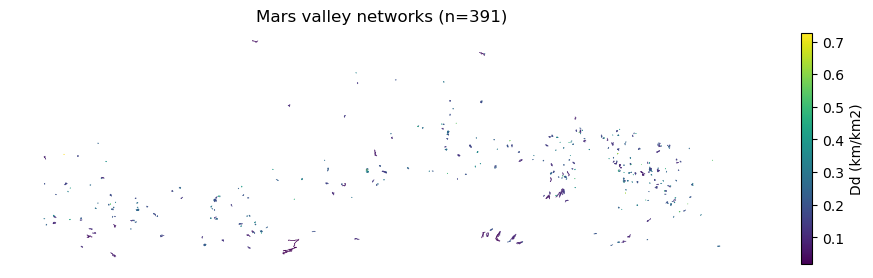

In [5]:
import geopandas as gpd
try:
    seg = gpd.read_file(gpkg, layer='mars_segments')
    if 'network_id' in seg.columns:
        seg = seg.merge(ok[['network_id', 'dd_hull_km_km2']], on='network_id', how='left')
        col, kw = 'dd_hull_km_km2', dict(legend=True, legend_kwds={'label': 'Dd (km/km2)', 'shrink': 0.5})
    else:
        col, kw = None, {}
    fig, ax = plt.subplots(figsize=(12, 6))
    seg.plot(ax=ax, column=col, cmap='viridis', linewidth=0.5, **kw)
    ax.set_title('Mars valley networks (n=%d)' % len(ok)); ax.set_aspect('equal'); ax.axis('off'); plt.show()
except Exception as e:
    print('map unavailable:', e)

**Takeaway.** The 391 martian valley networks span a wide range of size but cluster
around a characteristic drainage density. That median Dd is the calibration target:
Stage 4 tunes the Earth pruning regimes so Earth's Dd brackets it, so any Earth→Mars
difference in coupling reflects geometry, not a complexity mismatch.